# INE 5420 - Computação Gráfica

 * http://www.lapix.ufsc.br/ensino/computacao-grafica/

<a href="https://colab.research.google.com/drive/1-o4NErMUjMSHBvJDrkTs_b1w4rtz4HCa"><img align="left"  src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab" title="Open and Execute in Google Colaboratory"></a>&nbsp; &nbsp;<a href=""><img align="left" src="http://www.lapix.ufsc.br/wp-content/uploads/2019/04/License-CC-BY-ND-4.0-orange.png" alt="Creative Commons 4.0 License" title="Creative Commons 4.0 License"></a>&nbsp; &nbsp; <a href=""><img align="left" src="http://www.lapix.ufsc.br/wp-content/uploads/2019/04/Jupyter-Notebook-v.1.0-blue.png" alt="Jupyter Version" title="Jupyter Version"></a>&nbsp; &nbsp;<a href=""><img align="left"  src="http://www.lapix.ufsc.br/wp-content/uploads/2019/04/Python-v.3.7-green.png" alt="Python Version" title="Python Version"></a>

## SymPy

SymPy is a Python library for symbolic mathematics. It aims to become a full-featured computer algebra system (CAS) while keeping the code as simple as possible in order to be comprehensible and easily extensible.

 * [SymPy Homepage](https://www.sympy.org/en/index.html)

In [1]:
# Install the package
!conda install sympy
import matplotlib.pyplot as plt

zsh:1: command not found: conda


In [2]:
# If you don't use Anaconda then:
!pip install sympy
import matplotlib.pyplot as plt

zsh:1: command not found: pip


## Initializations

In [3]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np


In [4]:
# Import symbolic computation packages
from sympy import *
from sympy.geometry import Point
# Import algebraic symbols capabilities
from sympy import symbols
# Allow for some pretty printing...
# If you're using Jupyter Notebooks uncomment this one:
# init_printing(use_unicode=True)
# If you're using Google Colab uncomment this one:
init_printing(use_latex=False)
# If nothing works, the use this last resort, painting the formulas with matplotlib:
# init_printing(use_latex='matplotlib')

## Exemplo de Computação Gráfica: curva B-Spline em 2D

Usefull infos:
 * https://docs.sympy.org/latest/tutorial/matrices.html

 Remember:
 * the general formula of a Parametric Curve is T * M * G, where:
   * T is the line matrix that represents the parameter vector,
   * M is the square method matrix (Hermite, Bèzier or B-Spline) and
   * G is the column geometry vector

In [5]:
# SymPy always considers a sequence of scalars to be building a Column Matrix.
# In order to build a Line Matrix you'll have to transpose it after creation...
t = symbols('t')
T = Matrix([t**3, t**2, t, 1])
#T = Matrix([[t**3], [t**2], [t], [1]])
T = T.transpose()
T

⎡ 3   2      ⎤
⎣t   t   t  1⎦

In [6]:
# Create the Bèzier Method Matrix Mb
Mb = Matrix([[-1, 3, -3, 1], [3,-6, 3, 0], [-3, 3, 0, 0],[1, 0, 0, 0]])
Mb

⎡-1  3   -3  1⎤
⎢             ⎥
⎢3   -6  3   0⎥
⎢             ⎥
⎢-3  3   0   0⎥
⎢             ⎥
⎣1   0   0   0⎦

Now, test T * M:

In [7]:
# Create the B-Spline Method Matrix Mbs
Mbs = Matrix([[-1, 3, -3, 1], [3,-6, 3, 0], [-3, 0, 3, 0],[1, 4, 1, 0]])
Mbs = Mbs /6
Mbs

⎡-1/6  1/2  -1/2  1/6⎤
⎢                    ⎥
⎢1/2   -1   1/2    0 ⎥
⎢                    ⎥
⎢-1/2   0   1/2    0 ⎥
⎢                    ⎥
⎣1/6   2/3  1/6    0 ⎦

In [8]:
T * Mbs

⎡   3    2           3              3    2           3⎤
⎢  t    t    t   1  t     2   2    t    t    t   1  t ⎥
⎢- ── + ── - ─ + ─  ── - t  + ─  - ── + ── + ─ + ─  ──⎥
⎣  6    2    2   6  2         3    2    2    2   6  6 ⎦

 * https://docs.sympy.org/latest/modules/geometry/points.html

In [9]:
# Os 10 pontos de controle do enunciado (idênticos aos do exercício de Bézier).
p1  = Point2D(1, 1)
p2  = Point2D(2, 3)
p3  = Point2D(3, 0)
p4  = Point2D(4, 1)
p5  = Point2D(5, 2)
p6  = Point2D(4, 4)
p7  = Point2D(6, 4)
p8  = Point2D(7, 4)
p9  = Point2D(6, 2)
p10 = Point2D(7, 1)
control = [p1, p2, p3, p4, p5, p6, p7, p8, p9, p10]
control

[Point2D(1, 1), Point2D(2, 3), Point2D(3, 0), Point2D(4, 1), Point2D(5, 2), Po ↪

↪ int2D(4, 4), Point2D(6, 4), Point2D(7, 4), Point2D(6, 2), Point2D(7, 1)]

In [10]:
# A B-Spline cúbica uniforme sobre N pontos de controle tem N-3 segmentos, cada um
# definido por uma janela deslizante de 4 pontos consecutivos. Para 10 pontos são 7
# segmentos: P1-P4, P2-P5, ..., P7-P10.
# Gx/Gy são os vetores-geometria (coluna) de UMA janela; um por eixo.
def geometry(i):
    janela = control[i:i + 4]
    Gx = Matrix([p.x for p in janela])
    Gy = Matrix([p.y for p in janela])
    return Gx, Gy

Gx, Gy = geometry(0)
Gx

⎡1⎤
⎢ ⎥
⎢2⎥
⎢ ⎥
⎢3⎥
⎢ ⎥
⎣4⎦

In [11]:
Gy

⎡1⎤
⎢ ⎥
⎢3⎥
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣1⎦

Função de mistura (*blending*) da coordenada x do primeiro segmento, usando a matriz base **B-Spline** `Mbs` (não a de Bézier): `fx = T * Mbs * Gx`.

In [12]:
fx = T * Mbs * Gx
# fx ainda é uma matriz 1x1; extraia a expressão da posição zero:
fx = fx[0]
fx

t + 2

Generate the Blending function for the y-Coordinates:

In [13]:
fy = T * Mbs * Gy
# fy ainda é uma matriz 1x1; extraia a expressão da posição zero:
fy = fy[0]
fy

   3      2         
3⋅t    5⋅t    t   13
──── - ──── - ─ + ──
 2      2     2   6 

### Diferenças Adiante (Forward Differences)

Uma coordenada de um segmento é a cúbica $C(t) = a\,t^3 + b\,t^2 + c\,t + d$, cujos coeficientes $[a,b,c,d]$ saem de $M_{bs} \cdot G$ (por eixo). Em vez de reavaliar $T \cdot M_{bs} \cdot G$ a cada $t$ (o que exige multiplicações), as **Diferenças Adiante** avançam a cúbica só com somas.

Com passo $\Delta = 1/n$, as condições iniciais (C.I.) são:

$$f_0 = d, \quad \Delta f = a\Delta^3 + b\Delta^2 + c\Delta, \quad \Delta^2 f = 6a\Delta^3 + 2b\Delta^2, \quad \Delta^3 f = 6a\Delta^3$$

e a atualização, repetida $n$ vezes, é apenas:

$$f \mathrel{+}= \Delta f, \quad \Delta f \mathrel{+}= \Delta^2 f, \quad \Delta^2 f \mathrel{+}= \Delta^3 f$$

O mapeamento dos coeficientes para as C.I. é ele próprio uma matriz (a matriz $\delta$); geramos uma matriz $\delta$ / conjunto de C.I. por segmento (7 ao todo).

In [14]:
# A matriz de Diferenças Adiante E(Δ): leva os coeficientes [a,b,c,d] às C.I.
# [f, Δf, Δ²f, Δ³f]. É a "matriz δ" do enunciado, uma por segmento (aqui só muda a
# geometria, então E é a mesma para todos os 7).
def delta_matrix(delta):
    d1, d2, d3 = delta, delta**2, delta**3
    return Matrix([
        [0,        0,      0,  1],
        [d3,       d2,     d1, 0],
        [6*d3,     2*d2,   0,  0],
        [6*d3,     0,      0,  0],
    ])

# C.I. de uma coordenada: coeffs = Mbs * G (por eixo), estado = E(Δ) * coeffs.
def initial_conditions(G, delta):
    coeffs = Mbs * G          # [a, b, c, d] da cúbica dessa coordenada
    return delta_matrix(delta) * coeffs

# Demonstração no segmento 0, coordenada x (passo Δ = 1/50):
delta = Rational(1, 50)
initial_conditions(Gx, delta)   # [f, Δf, Δ²f, Δ³f]

⎡ 2  ⎤
⎢    ⎥
⎢1/50⎥
⎢    ⎥
⎢ 0  ⎥
⎢    ⎥
⎣ 0  ⎦

In [15]:
# Passo: n subdivisões por segmento -> n+1 amostras (Δ = 1/n).
n = 50
delta = Rational(1, n)

def sample_segment(i):
    """Amostra o segmento i (janela P[i]..P[i+3]) por Diferenças Adiante."""
    Gx, Gy = geometry(i)
    fx, dfx, d2fx, d3fx = initial_conditions(Gx, delta)
    fy, dfy, d2fy, d3fy = initial_conditions(Gy, delta)
    xs, ys = [], []
    for _ in range(n + 1):
        xs.append(fx); ys.append(fy)
        # Atualização por Diferenças Adiante -- só somas.
        fx += dfx; dfx += d2fx; d2fx += d3fx
        fy += dfy; dfy += d2fy; d2fy += d3fy
    return xs, ys

# Percorre os 7 segmentos. Segmentos vizinhos se encontram numa junção comum, então
# todo segmento após o primeiro descarta seu ponto em t=0 para não duplicar.
xs, ys = [], []
n_segmentos = len(control) - 3
for i in range(n_segmentos):
    sx, sy = sample_segment(i)
    if i == 0:
        xs += sx;      ys += sy
    else:
        xs += sx[1:];  ys += sy[1:]

# subs() manteve tudo simbólico (Rational); float() para plotar.
xs = [float(x) for x in xs]
ys = [float(y) for y in ys]
print(n_segmentos, 'segmentos,', len(xs), 'pontos')

7 segmentos, 351 pontos


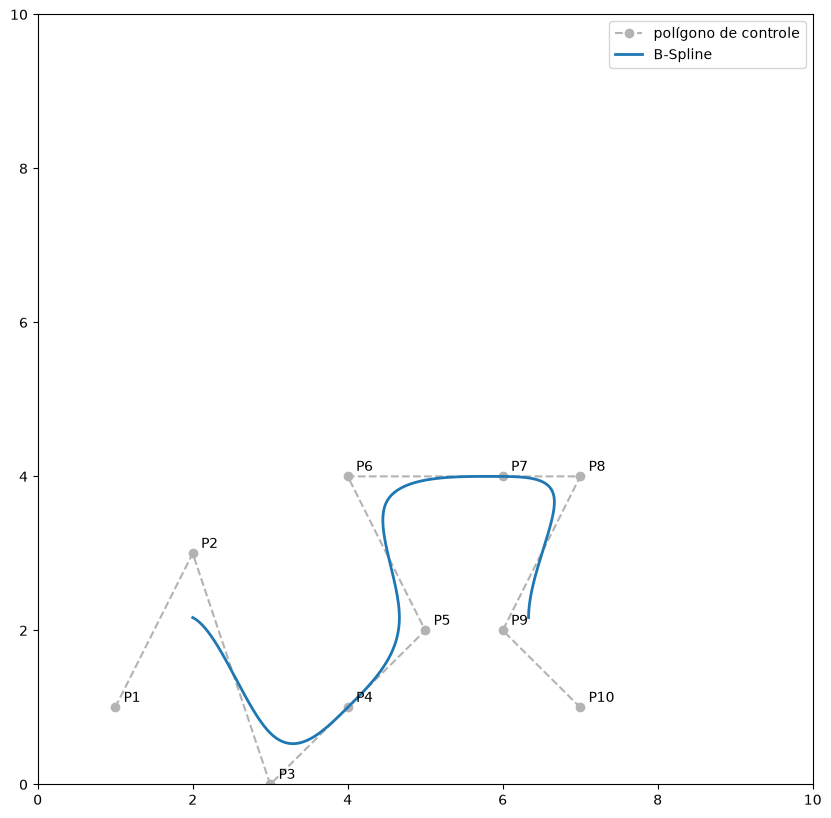

In [16]:
fig = plt.figure(figsize=(10, 10))  # figura 10 por 10 polegadas
plt.xlim(0, 10)
plt.ylim(0, 10)
# Polígono de controle (tracejado) + os 10 pontos rotulados.
cx = [float(p.x) for p in control]
cy = [float(p.y) for p in control]
plt.plot(cx, cy, 'o--', color='0.7', label='polígono de controle')
for k, p in enumerate(control, start=1):
    plt.annotate(f'P{k}', (float(p.x), float(p.y)), textcoords='offset points', xytext=(6, 4))
# A curva B-Spline gerada por Diferenças Adiante.
plt.plot(xs, ys, color='tab:blue', linewidth=2, label='B-Spline')
plt.legend()
plt.show()